In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [2]:
import pandas as pd

# Ruta del archivo CSV
DATASET_DIR = "sim_001_full_overlaps.csv"

# Cargar dataset
df = pd.read_csv(DATASET_DIR)

# --- Información general ---
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:\n", df.columns.tolist())

# --- Separar columnas por tipo ---
time_col = [col for col in df.columns if col.lower() == "time"]
fault_cols = [col for col in df.columns if col.startswith("fault_")]
output_cols = [col for col in df.columns 
               if col not in fault_cols and col not in time_col]

print("\nColumna de tiempo:", time_col)
print("Columnas de fallas (fault_*):", fault_cols)
print("Columnas de outputs:", output_cols)
print("\nNúmero de fallas:", len(fault_cols))
print("Número de outputs:", len(output_cols))

# --- Mostrar primeras 5 filas ---
print("\nPrimeras filas del dataset:")
display(df.head())

# --- Resumen estadístico general ---
print("\nResumen estadístico:")
display(df.describe())


Dimensiones del dataset: (400001, 38)

Columnas:
 ['Time', 'fault_ss1', 'fault_ss2', 'fault_ss3', 'fault_ss4', 'fault_ss5', 'fault_ss6', 'fault_magn1', 'fault_magn2', 'fault_magn3', 'fault_gyro1', 'fault_gyro2', 'fault_gyro3', 'fault_gps1', 'fault_gps2', 'fault_gps3', 'fault_mtq1', 'fault_mtq2', 'fault_mtq3', 'Vout_ss_1', 'Vout_ss_2', 'Vout_ss_3', 'Vout_ss_4', 'Vout_ss_5', 'Vout_ss_6', 'Bout_magn_1', 'Bout_magn_2', 'Bout_magn_3', 'wout_gyro_1', 'wout_gyro_2', 'wout_gyro_3', 'out_gps_1', 'out_gps_2', 'out_gps_3', 'mout_mtq_1', 'mout_mtq_2', 'mout_mtq_3', 'point_error_1']

Columna de tiempo: ['Time']
Columnas de fallas (fault_*): ['fault_ss1', 'fault_ss2', 'fault_ss3', 'fault_ss4', 'fault_ss5', 'fault_ss6', 'fault_magn1', 'fault_magn2', 'fault_magn3', 'fault_gyro1', 'fault_gyro2', 'fault_gyro3', 'fault_gps1', 'fault_gps2', 'fault_gps3', 'fault_mtq1', 'fault_mtq2', 'fault_mtq3']
Columnas de outputs: ['Vout_ss_1', 'Vout_ss_2', 'Vout_ss_3', 'Vout_ss_4', 'Vout_ss_5', 'Vout_ss_6', 'Bout_magn_

,Time,fault_ss1,fault_ss2,fault_ss3,fault_ss4,fault_ss5,fault_ss6,fault_magn1,fault_magn2,fault_magn3,...,wout_gyro_1,wout_gyro_2,wout_gyro_3,out_gps_1,out_gps_2,out_gps_3,mout_mtq_1,mout_mtq_2,mout_mtq_3,point_error_1
0,0.0,0,0,0,0,0,0,0,0,0,...,32761,32791,32783,3.784552e+06,4.764665e+06,2.967833e+06,-0.09375,-0.09375,-0.09375,67.027648
1,0.1,0,0,0,0,0,0,0,0,0,...,32763,32790,32782,3.783931e+06,4.764934e+06,2.968194e+06,-0.09375,-0.09375,-0.09375,67.012292
2,0.2,0,0,0,0,0,0,0,0,0,...,32765,32789,32781,3.783309e+06,4.765203e+06,2.968555e+06,-0.09375,-0.09375,-0.09375,66.998087
3,0.3,0,0,0,0,0,0,0,0,0,...,32767,32788,32779,3.782687e+06,4.765472e+06,2.968915e+06,-0.09375,-0.09375,-0.09375,66.985030
4,0.4,0,0,0,0,0,0,0,0,0,...,32769,32787,32778,3.782066e+06,4.765740e+06,2.969276e+06,-0.09375,-0.09375,-0.09375,66.973124



Resumen estadístico:


,Time,fault_ss1,fault_ss2,fault_ss3,fault_ss4,fault_ss5,fault_ss6,fault_magn1,fault_magn2,fault_magn3,...,wout_gyro_1,wout_gyro_2,wout_gyro_3,out_gps_1,out_gps_2,out_gps_3,mout_mtq_1,mout_mtq_2,mout_mtq_3,point_error_1
count,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,400001.000000,...,400001.000000,400001.000000,400001.000000,4.000010e+05,4.000010e+05,4.000010e+05,400001.000000,400001.000000,400001.000000,400001.000000
mean,20000.000000,0.021235,0.021900,0.020722,0.022045,0.019820,0.020707,0.037757,0.038395,0.038305,...,32767.854595,32768.326259,32770.258689,-6.540885e+03,1.443995e+05,1.202563e+05,-0.000002,0.000033,0.000049,50.197889
std,11547.048685,0.144167,0.146357,0.142454,0.146830,0.139381,0.142403,0.190609,0.192148,0.191932,...,9.301768,7.266002,7.692790,4.634205e+06,3.776392e+06,3.088582e+06,0.000628,0.000607,0.000619,33.372717
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,32723.000000,32742.000000,32708.000000,-7.040070e+06,-5.699028e+06,-4.854902e+06,-0.093750,-0.093750,-0.093750,1.028247
25%,10000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,32762.000000,32763.000000,32765.000000,-4.542508e+06,-3.636035e+06,-2.970519e+06,-0.000044,-0.000038,-0.000011,24.712595
50%,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,32769.000000,32768.000000,32772.000000,8.696517e+04,2.200376e+05,2.000000e+05,-0.000020,-0.000011,0.000014,43.346304
75%,30000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,32775.000000,32774.000000,32776.000000,4.560026e+06,3.951391e+06,3.247464e+06,-0.000002,0.000020,0.000038,64.078202
max,40000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,32783.000000,32791.000000,32790.000000,7.462841e+06,6.060684e+06,5.220764e+06,0.009036,0.008918,0.008772,166.818181


In [4]:
#Sliding window
import numpy as np

window_size = 20

fault_cols = [c for c in df.columns if c.startswith("fault_")]
output_cols = [c for c in df.columns if c not in fault_cols and c != "time"]

X = []
y_bin = []
y_ch = []

for start in range(0, len(df) - window_size + 1):
    end = start + window_size
    window = df.iloc[start:end]

    # Input: 20x19 outputs
    X.append(window[output_cols].values)

    # Binary anomaly: any fault active in the window
    y_bin.append(int(window[fault_cols].values.max() == 1))

    # Multi-label fault vector
    y_ch_vec = (window[fault_cols].values.max(axis=0)).astype(int)
    y_ch.append(y_ch_vec)

X = np.array(X)
y_bin = np.array(y_bin)
y_ch = np.array(y_ch)

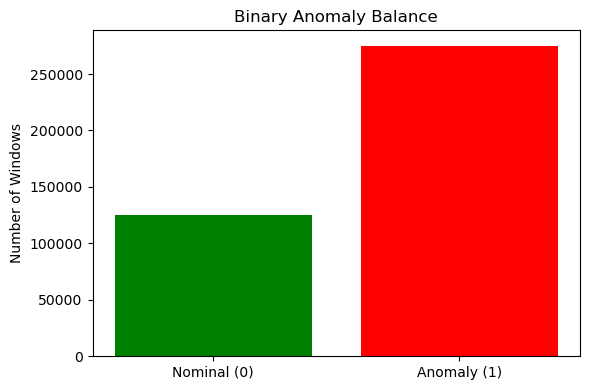

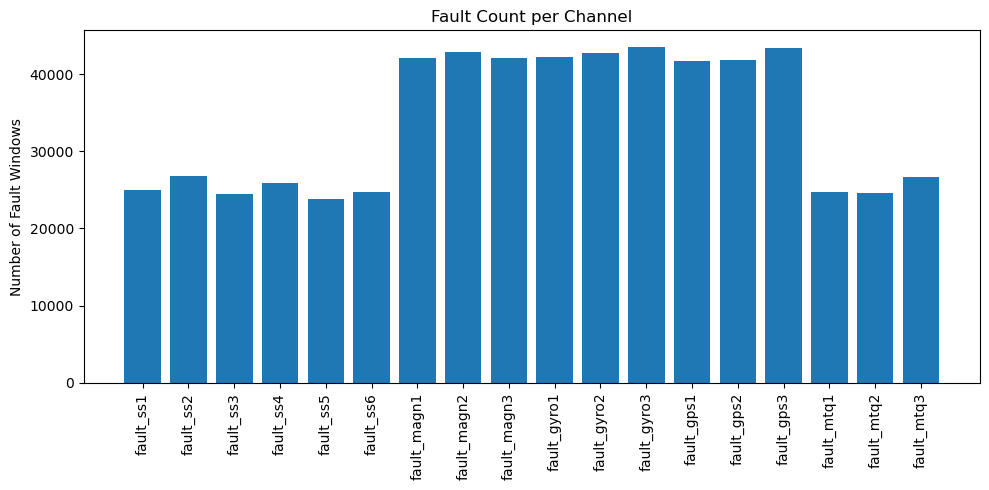

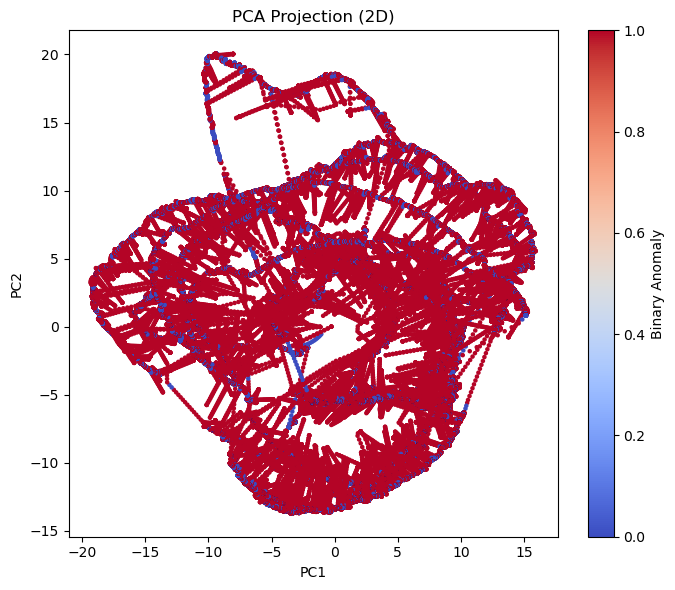

/opt/conda/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
# separar nominales
X_nom = X[y_bin == 0]   # (N_nom, 20, num_features)
# calcular μ y σ por feature
mean_feat = X_nom.mean(axis=(0,1))   # (num_features,)
std_feat  = X_nom.std(axis=(0,1)) + 1e-8
# escalar TODO el dataset
def scale_windows(X, mean, std):
    return (X - mean[None,None,:]) / std[None,None,:]

X_scaled = scale_windows(X, mean_feat, std_feat)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# ============================
# 1. Balance: Nominal vs Anomaly
# ============================
plt.figure(figsize=(6,4))
unique, counts = np.unique(y_bin, return_counts=True)
plt.bar(['Nominal (0)', 'Anomaly (1)'], counts, color=['green', 'red'])
plt.title("Binary Anomaly Balance")
plt.ylabel("Number of Windows")
plt.tight_layout()
plt.show()

# ============================
# 2. Faults per channel
# ============================
fault_counts = y_ch.sum(axis=0)

plt.figure(figsize=(10,5))
plt.bar(fault_cols, fault_counts)
plt.title("Fault Count per Channel")
plt.ylabel("Number of Fault Windows")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ============================
# 3. PCA Separability (2D)
# ============================
X_flat = X_scaled.reshape(X_scaled.shape[0], -1)   # flatten windows -> 20*#outputs
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=y_bin, cmap='coolwarm', s=5)
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Binary Anomaly")
plt.tight_layout()
plt.show()

# ============================
# 4. t-SNE Separability (2D)
# ============================
# Only take a subset if dataset is huge
subset = min(8000, len(X_flat))
idx = np.random.choice(len(X_flat), subset, replace=False)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
X_tsne = tsne.fit_transform(X_flat[idx])

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=y_bin[idx], cmap='coolwarm', s=5)
plt.title("t-SNE Projection (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Binary Anomaly")
plt.tight_layout()
plt.show()

# ============================
# 5. Samples per Fault Type (multilabel)
# ============================
plt.figure(figsize=(8,5))
total_multilabel = y_ch.sum(axis=0)
plt.bar(fault_cols, total_multilabel)
plt.title("Per-Channel Fault Activation (Windowed)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ============================
# 6. Correlation between Outputs
# ============================
import pandas as pd

plt.figure(figsize=(10,8))
sns.heatmap(df[output_cols].corr(), cmap="viridis")
plt.title("Output Signal Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================
# 7. Fault Co-Occurrence Matrix
# ============================
co_matrix = np.zeros((len(fault_cols), len(fault_cols)))

for row in y_ch:
    co_matrix += np.outer(row, row)

plt.figure(figsize=(8,7))
sns.heatmap(co_matrix, cmap="magma", xticklabels=fault_cols, yticklabels=fault_cols)
plt.title("Fault Co-Occurrence Matrix")
plt.tight_layout()
plt.show()

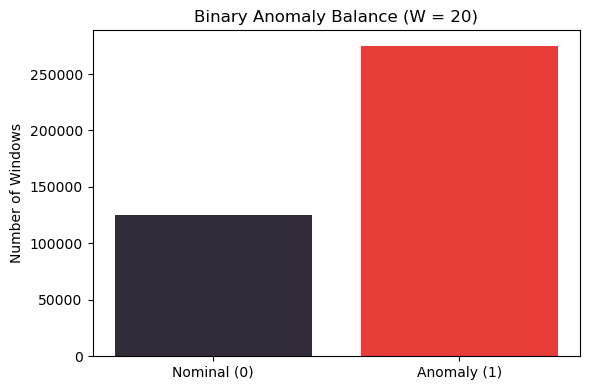

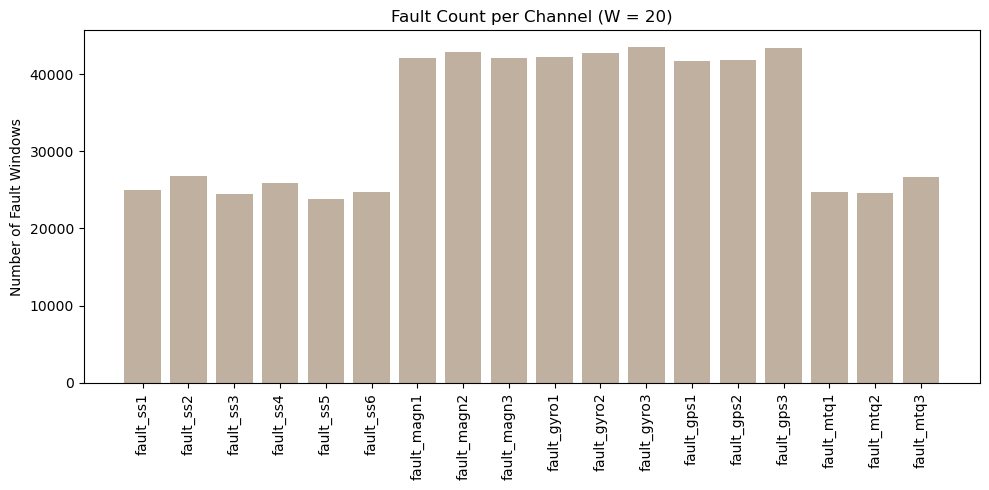

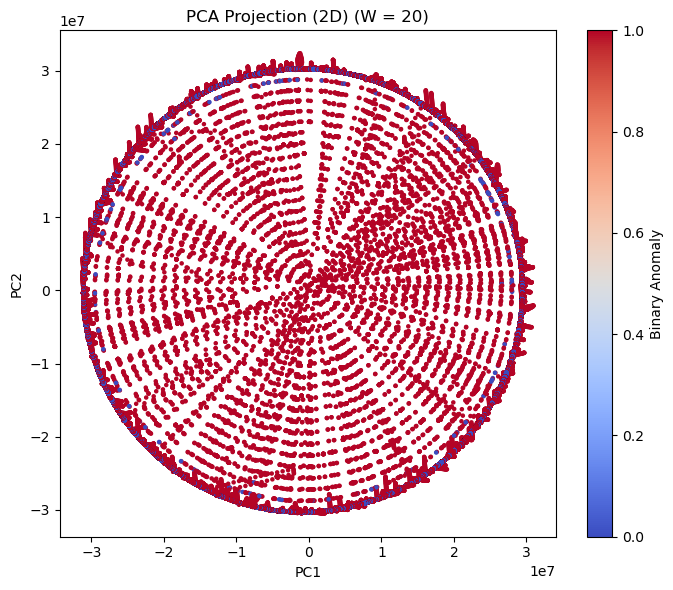

/opt/conda/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


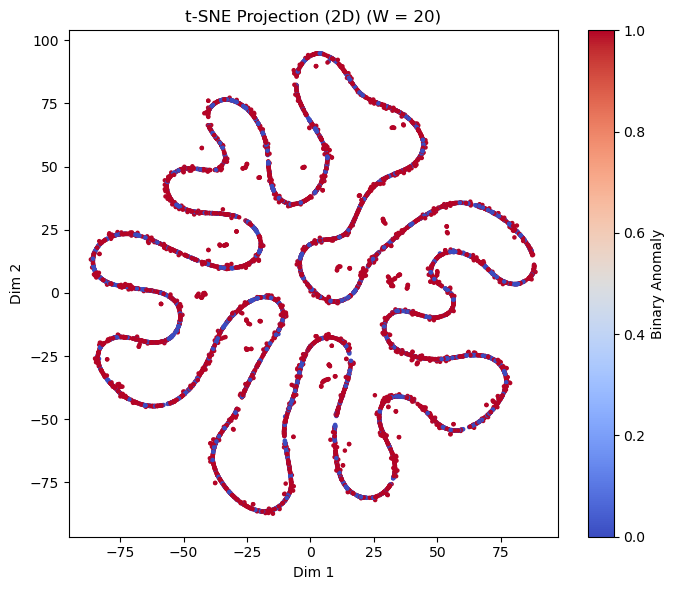

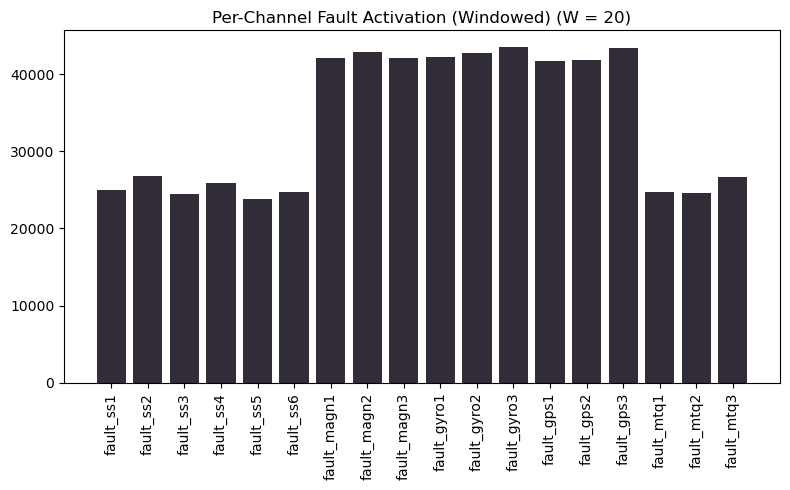

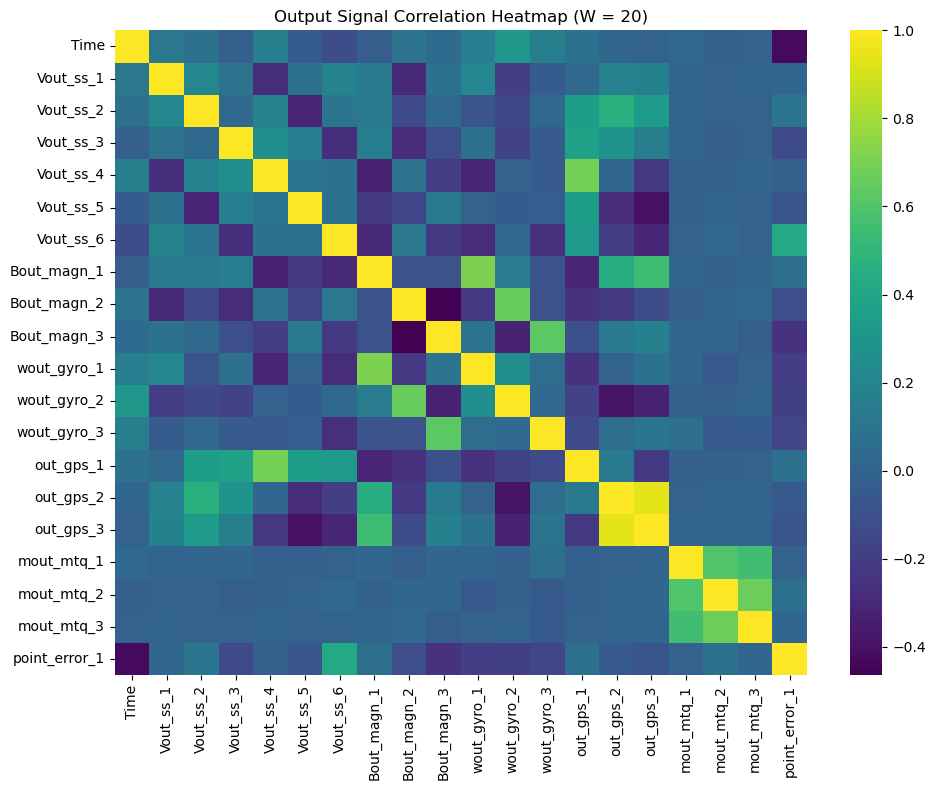

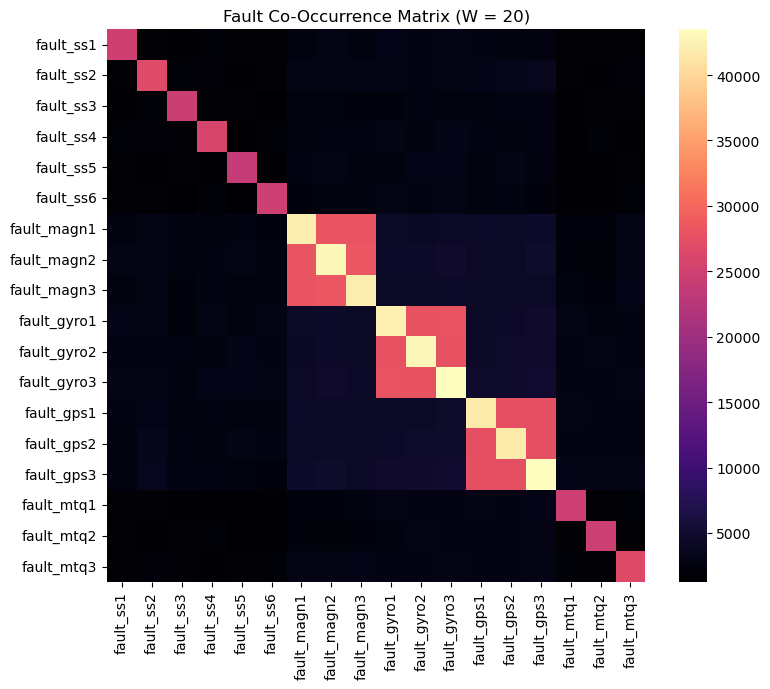

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# ============================
# 1. Balance: Nominal vs Anomaly
# ============================
plt.figure(figsize=(6,4))
unique, counts = np.unique(y_bin, return_counts=True)
plt.bar(['Nominal (0)', 'Anomaly (1)'], counts, color=['#312c38', '#e73c37'])
plt.title("Binary Anomaly Balance (W = 20)")
plt.ylabel("Number of Windows")
plt.tight_layout()
plt.savefig("./fig20/NomvsAnom_w20.png", dpi=600)
plt.show()

# ============================
# 2. Faults per channel
# ============================
fault_counts = y_ch.sum(axis=0)

plt.figure(figsize=(10,5))
plt.bar(fault_cols, fault_counts, color ="#bfb0a0")
plt.title("Fault Count per Channel (W = 20)")
plt.ylabel("Number of Fault Windows")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("fig20/FaultspCh_w20.png", dpi=600)
plt.show()

# ============================
# 3. PCA Separability (2D)
# ============================
X_flat = X.reshape(X.shape[0], -1)   # flatten windows -> 20*#outputs
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=y_bin, cmap='coolwarm', s=5)
plt.title("PCA Projection (2D) (W = 20)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Binary Anomaly")
plt.tight_layout()
plt.savefig("figw20/PCA2DNoscale_w20.png", dpi=600)
plt.show()

# ============================
# 4. t-SNE Separability (2D)
# ============================
# Only take a subset if dataset is huge
subset = min(8000, len(X_flat))
idx = np.random.choice(len(X_flat), subset, replace=False)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
X_tsne = tsne.fit_transform(X_flat[idx])

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=y_bin[idx], cmap='coolwarm', s=5)
plt.title("t-SNE Projection (2D) (W = 20)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Binary Anomaly")
plt.tight_layout()
plt.savefig("fig20/tsne_w20.png", dpi=600)
plt.show()

# ============================
# 5. Samples per Fault Type (multilabel)
# ============================
plt.figure(figsize=(8,5))
total_multilabel = y_ch.sum(axis=0)
plt.bar(fault_cols, total_multilabel, color = "#312c38")
plt.title("Per-Channel Fault Activation (Windowed) (W = 20)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("fig20/samples_w20.png", dpi=600)
plt.show()

# ============================
# 6. Correlation between Outputs
# ============================
import pandas as pd

plt.figure(figsize=(10,8))
sns.heatmap(df[output_cols].corr(), cmap="viridis")
plt.title("Output Signal Correlation Heatmap (W = 20)")
plt.tight_layout()
plt.savefig("fig20/Corr_w20.png", dpi=600)
plt.show()

# ============================
# 7. Fault Co-Occurrence Matrix
# ============================
co_matrix = np.zeros((len(fault_cols), len(fault_cols)))

for row in y_ch:
    co_matrix += np.outer(row, row)

plt.figure(figsize=(8,7))
sns.heatmap(co_matrix, cmap="magma", xticklabels=fault_cols, yticklabels=fault_cols)
plt.title("Fault Co-Occurrence Matrix (W = 20)")
plt.tight_layout()
plt.savefig("fig20/CoOcurr_w20.png", dpi=600)
plt.show()


In [11]:
X = np.array(X)         # (N, 20, num_features)
y_bin = np.array(y_bin) # (N,)
y_ch = np.array(y_ch)   # (N, 18)

print("Final dataset")
print("X:", X.shape)
print("y_bin:", np.bincount(y_bin))
print("y_ch:", y_ch.shape)
# work/srv21/windowed_dataset
SAVE_DIR = "./dataset_windows20/"
np.save(SAVE_DIR + "X_windows.npy", X)
np.save(SAVE_DIR + "y_binary.npy", y_bin)
np.save(SAVE_DIR + "y_channel.npy", y_ch)


Final dataset
X: (399982, 20, 20)
y_bin: [125011 274971]
y_ch: (399982, 18)


In [8]:
import numpy as np

idx_nom = np.where(y_bin == 0)[0]
idx_anom = np.where(y_bin == 1)[0]

print("Nominal windows:", len(idx_nom))
print("Anomalous windows:", len(idx_anom))


Nominal windows: 125011
Anomalous windows: 274971


In [6]:
np.random.seed(42)

n_target = len(idx_nom)

idx_anom_sub = np.random.choice(
    idx_anom,
    size=n_target,
    replace=False
)

idx_bal = np.concatenate([idx_nom, idx_anom_sub])
np.random.shuffle(idx_bal)


In [7]:
X_bal = X[idx_bal]
y_bin_bal = y_bin[idx_bal]
y_ch_bal = y_ch[idx_bal]

print("Balanced dataset:")
print("X:", X_bal.shape)
print("Binary labels:", np.bincount(y_bin_bal))


Balanced dataset:
X: (250022, 20, 20)
Binary labels: [125011 125011]


In [9]:
def dataset_report(X, y_bin, y_ch, window_size):
    n_windows, win_size, n_feat = X.shape
    n_nom = np.sum(y_bin == 0)
    n_anom = np.sum(y_bin == 1)

    print("="*60)
    print("DATASET HEALTH REPORT")
    print("="*60)

    print(f"Total windows           : {n_windows}")
    print(f"Window size             : {win_size}")
    print(f"Number of features      : {n_feat}")
    print(f"Nominal windows         : {n_nom}")
    print(f"Anomalous windows       : {n_anom}")
    print(f"Anomaly ratio           : {n_anom / n_windows:.3f}")
    print()

    # Per-channel statistics
    ch_counts = y_ch.sum(axis=0)
    print("Fault occurrence per channel:")
    for i, cnt in enumerate(ch_counts):
        print(f"  Channel {i+1:02d}: {int(cnt)} windows")

    print()
    print("Parallel fault statistics:")
    n_parallel = np.sum(y_ch.sum(axis=1) > 1)
    print(f"  Windows with >1 fault  : {n_parallel}")
    print(f"  Parallel fault ratio   : {n_parallel / n_windows:.3f}")

    print("="*60)


In [10]:
dataset_report(X, y_bin, y_ch, window_size)


DATASET HEALTH REPORT
Total windows           : 399982
Window size             : 20
Number of features      : 20
Nominal windows         : 125011
Anomalous windows       : 274971
Anomaly ratio           : 0.687

Fault occurrence per channel:
  Channel 01: 24924 windows
  Channel 02: 26763 windows
  Channel 03: 24498 windows
  Channel 04: 25831 windows
  Channel 05: 23838 windows
  Channel 06: 24730 windows
  Channel 07: 42108 windows
  Channel 08: 42902 windows
  Channel 09: 42111 windows
  Channel 10: 42202 windows
  Channel 11: 42745 windows
  Channel 12: 43492 windows
  Channel 13: 41722 windows
  Channel 14: 41803 windows
  Channel 15: 43372 windows
  Channel 16: 24719 windows
  Channel 17: 24629 windows
  Channel 18: 26611 windows

Parallel fault statistics:
  Windows with >1 fault  : 154771
  Parallel fault ratio   : 0.387
